In [ ]:
#installing kagglehub
!pip install kagglehub
import kagglehub
path = kagglehub.dataset_download("kwentar/blur-dataset")
print(path)

Using Colab cache for faster access to the 'blur-dataset' dataset.
/kaggle/input/blur-dataset


In [ ]:
import os
path =  "/kaggle/input/blur-dataset"
print(os.listdir(path))

['defocused_blurred', 'sharp', 'motion_blurred', 'blur_dataset_scaled']


In [ ]:
#getting the total count of sharp , blurry and motion blurry images
sharp_path = path + "/sharp"
blur_path = path +"/defocused_blurred"
motion_path = path + "/motion_blurred"
print ("sharp images:", len(os.listdir(sharp_path)))
print ("blurred images:" ,len(os.listdir(blur_path)))
print ("motion blurred:",len(os.listdir(motion_path)))

sharp images: 350
blurred images: 350
motion blurred: 350


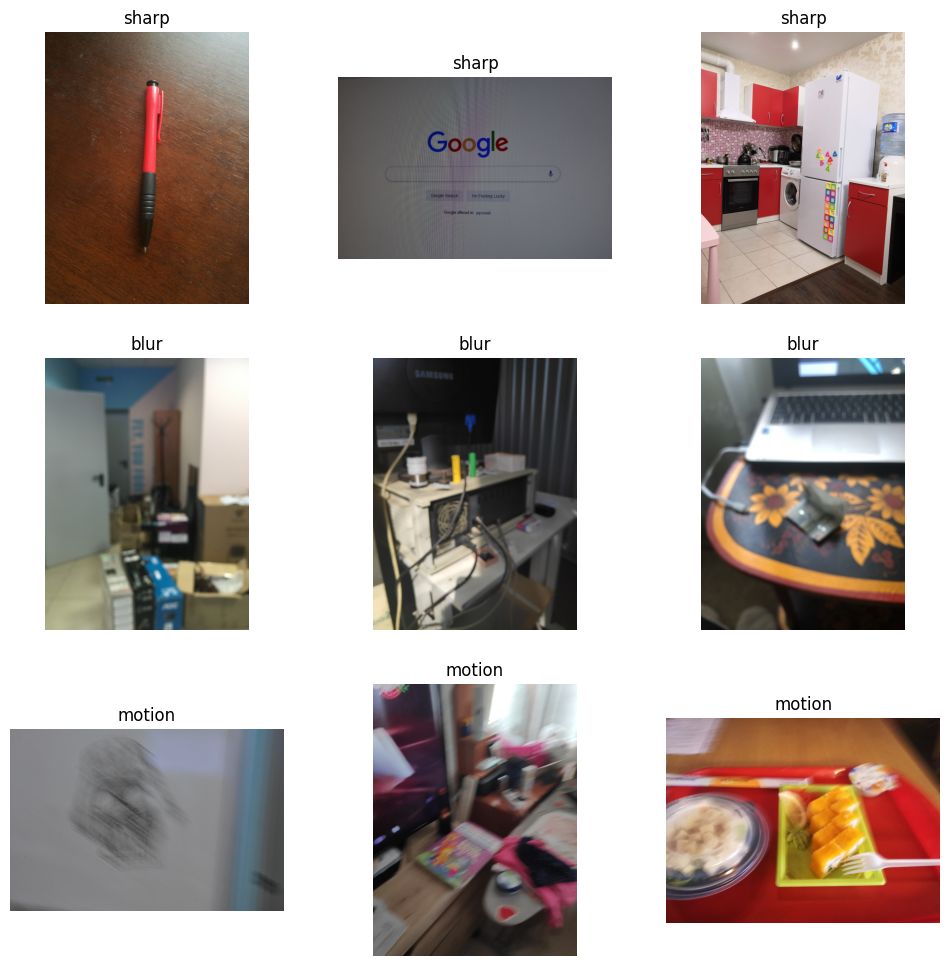

In [ ]:
#Loaded 1050 real blurry , motion blurred and sharp images
import matplotlib.pyplot as plt
import cv2
sharp_files = os.listdir(sharp_path)
blur_flies = os.listdir(blur_path)
motion_files = os.listdir(motion_path)
plt.figure(figsize=(12,12))
for i in range(3):
  img = cv2.imread(sharp_path +"/" + sharp_files[i])
  img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
  plt.subplot(3,3,i+1)
  plt.imshow(img)
  plt.axis("off")
  plt.title("sharp")

for i in range(3):
  img = cv2.imread(blur_path +"/" + blur_flies[i])
  img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
  plt.subplot(3,3,i+4)
  plt.imshow(img)
  plt.axis("off")
  plt.title("blur")

for i in range(3):
  img = cv2.imread(motion_path +"/" + motion_files[i])
  img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
  plt.subplot(3,3,i+7)
  plt.imshow(img)
  plt.axis("off")
  plt.title("motion")
plt.show()

In [ ]:
#Preprocessed and normalised them
images = []
labels = []
for file in sharp_files:
  img = cv2.imread(sharp_path + "/" + file)
  img = cv2.resize(img, (96, 96))
  images.append(img)
  labels.append(0)

for file in blur_flies:
  img = cv2.imread(blur_path + "/" + file)
  img = cv2.resize(img, (96, 96))
  images.append(img)
  labels.append(1)

for file in motion_files:
  img = cv2.imread(motion_path + "/" + file)
  img = cv2.resize(img, (96, 96))
  images.append(img)
  labels.append(1)

import numpy as np
x = np.array(images)/255
y = np.array(labels)
print(x.shape)
print(y.shape)


(1050, 96, 96, 3)
(1050,)


In [ ]:
#Used transfer learning - MobileNetV2
from tensorflow.keras.applications import MobileNetV2
from sklearn.model_selection import train_test_split
from tensorflow import keras
from tensorflow.keras import layers
base_model = MobileNetV2(input_shape=(96,96,3) , include_top= False, weights= "imagenet")
base_model.trainable = False
x_train ,x_test, y_train, y_test = train_test_split(x,y ,  test_size = 0.2, random_state = 42)
print(x_train.shape)
print(x_test.shape)
model = keras.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(1, activation = "sigmoid")
])
model.compile(loss="binary_crossentropy", optimizer = "adam", metrics = ["accuracy"])
model.fit(x_train,y_train, epochs = 10)
model.evaluate(x_test, y_test)


(840, 96, 96, 3)
(210, 96, 96, 3)
Epoch 1/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 11s 229ms/step - accuracy: 0.6940 - loss: 0.6116
Epoch 2/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 6s 209ms/step - accuracy: 0.8500 - loss: 0.3595
Epoch 3/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 5s 192ms/step - accuracy: 0.9036 - loss: 0.2600
Epoch 4/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 10s 193ms/step - accuracy: 0.9310 - loss: 0.2110
Epoch 5/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 7s 248ms/step - accuracy: 0.9464 - loss: 0.1850
Epoch 6/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 5s 191ms/step - accuracy: 0.9571 - loss: 0.1564
Epoch 7/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 6s 240ms/step - accuracy: 0.9643 - loss: 0.1392
Epoch 8/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 5s 193ms/step - accuracy: 0.9726 - loss: 0.1250
Epoch 9/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 5s 193ms/step - accuracy: 0.9786 - loss: 0.1127
Epoch 10/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 6s 229ms/step - accuracy: 0.9833 - loss: 0.1029
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 188ms/step - accuracy: 0.8952 - loss: 0.2483


[0.24828054010868073, 0.8952381014823914]

In [ ]:
#changing base_model.trainable true to test fine-tuning
base_model.trainable = True
for layer in base_model.layers[:-20]:
    layer.trainable = False
model.compile(loss="binary_crossentropy", optimizer=keras.optimizers.Adam(0.00001), metrics=["accuracy"])
model.fit(x_train, y_train, epochs=5)
model.evaluate(x_test, y_test)

Epoch 1/5
27/27 ━━━━━━━━━━━━━━━━━━━━ 23s 308ms/step - accuracy: 0.9631 - loss: 0.1987
Epoch 2/5
27/27 ━━━━━━━━━━━━━━━━━━━━ 8s 293ms/step - accuracy: 0.9833 - loss: 0.1628
Epoch 3/5
27/27 ━━━━━━━━━━━━━━━━━━━━ 11s 330ms/step - accuracy: 0.9845 - loss: 0.1496
Epoch 4/5
27/27 ━━━━━━━━━━━━━━━━━━━━ 8s 305ms/step - accuracy: 0.9833 - loss: 0.1295
Epoch 5/5
27/27 ━━━━━━━━━━━━━━━━━━━━ 9s 271ms/step - accuracy: 0.9881 - loss: 0.1128
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 305ms/step - accuracy: 0.8714 - loss: 0.2932


[0.29321998357772827, 0.8714285492897034]

In [ ]:
# Build embedding extractor: MobileNetV2 backbone + GlobalAveragePooling
# (no Dense/classification layer — outputs raw 1280-dim feature vectors)
embedding_model = keras.Sequential([
    base_model,
    layers.GlobalAveragePooling2D()
])

# Extract embeddings for all test images
embeddings = embedding_model.predict(x_test)
print(embeddings.shape)
print("Sharp image embedding:", embeddings[0][:10])  # first 10 numbers
print("Blurry image embedding:", embeddings[1][:10])

from sklearn.metrics.pairwise import cosine_similarity
sim = cosine_similarity([embeddings[0]], [embeddings[1]])
print("Similarity:", sim)

# Compare two different sharp images (expect similarity, but not guaranteed high
# since these embeddings were trained for blur detection, not general similarity)
sim2 = cosine_similarity([embeddings[0]], [embeddings[2]])
print("Sharp vs Sharp similarity:", sim2)

7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 541ms/step
(210, 1280)
Sharp image embedding: [0.         0.         0.11772802 1.7811389  1.2709198  0.
 0.         0.26249442 0.         1.5072536 ]
Blurry image embedding: [0.3893574  0.         0.         1.1627026  0.03511079 0.
 0.         0.7416664  0.07371537 3.3425257 ]
Similarity: [[0.25094542]]
Sharp vs Sharp similarity: [[0.28836894]]
